In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import f1_score, average_precision_score, matthews_corrcoef, confusion_matrix
from rdkit.Chem import Draw
import matplotlib.image as mpimg

In [2]:
df = pd.read_csv('data/data.csv')
df_std = pd.read_csv('data/receptor_std.csv')

In [3]:
df_clean = df.dropna(axis=1).copy()
metadata_cols = ['molecule_chembl_id', 'canonical_smiles', 'pKi', 'active', 'source_count']
feature_cols = [col for col in df_clean.columns if (col not in metadata_cols and col != 'mol')]

df_clean = df_clean.loc[:, df_clean.nunique() > 1]

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except:
        return ""
    
df_clean['scaffold'] = df_clean['canonical_smiles'].apply(get_scaffold)
scaffold_groups = df_clean.groupby('scaffold').indices
scaffold_list = sorted(scaffold_groups.items(), key=lambda x: len(x[1]), reverse=True)

train_indices = []
test_indices = []
train_cutoff = int(0.8 * len(df_clean))

for scaffold, indices in scaffold_list:
    if len(train_indices) + len(indices) <= train_cutoff:
        train_indices.extend(indices)
    else:
        test_indices.extend(indices)

df_train = df_clean.iloc[train_indices].copy()
df_test = df_clean.iloc[test_indices].copy()

X_train_raw = df_train[feature_cols]
X_test_raw = df_test[feature_cols]

## Remove correlated features
- columns with NaN values and constant columns were already dropped
- there are many correlated features, which would cause problem in shap
- iterative removal of one feature in a pair with correlation above 0.75

In [4]:
print(f"Original feature count: {X_train_raw.shape[1]}")

Original feature count: 938


In [5]:
corr_matrix = X_train_raw.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

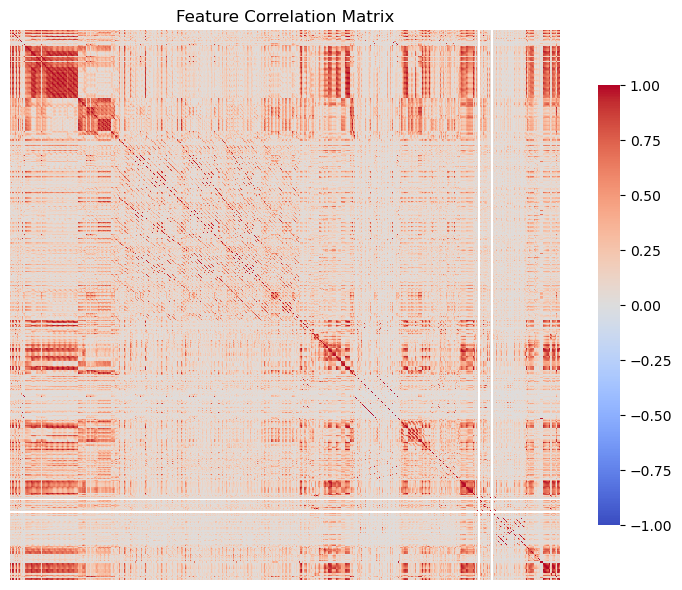

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(f"Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.75)]
print(f"Features to remove due to multicollinearity: {len(to_drop)}")

Features to remove due to multicollinearity: 734


In [8]:
X_train_filtered = X_train_raw.drop(columns=to_drop)
X_test_filtered = X_test_raw.drop(columns=to_drop)
retained_features = X_train_filtered.columns.tolist()
print(f"Final feature count: {len(retained_features)}")

Final feature count: 204


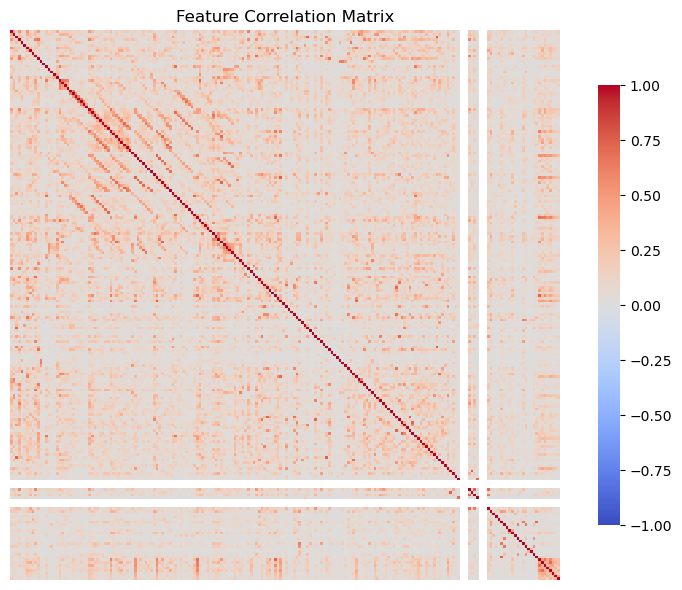

In [9]:
corr_matrix_after = X_train_filtered.corr().abs()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix_after,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(f"Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## XGBoost

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)
y_train = df_train['active'].values
y_test = df_test['active'].values

In [11]:
scale_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

In [12]:
xgb_model = XGBClassifier(
    scale_pos_weight=scale_weight, 
    random_state=42, 
    eval_metric='logloss',
    max_depth=5,
    n_estimators=100
)
xgb_model.fit(X_train_scaled, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [13]:

y_pred_xgb = xgb_model.predict(X_test_scaled)

mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Test MCC: {mcc_xgb:.3f}")
print("Test F1 Score:", f1_score(y_test, y_pred_xgb))
print("Test confusion matrix (TN, FP | FN, TP):\n", conf_matrix_xgb)

Test MCC: 0.558
Test F1 Score: 0.8488372093023255
Test confusion matrix (TN, FP | FN, TP):
 [[118  75]
 [ 29 292]]


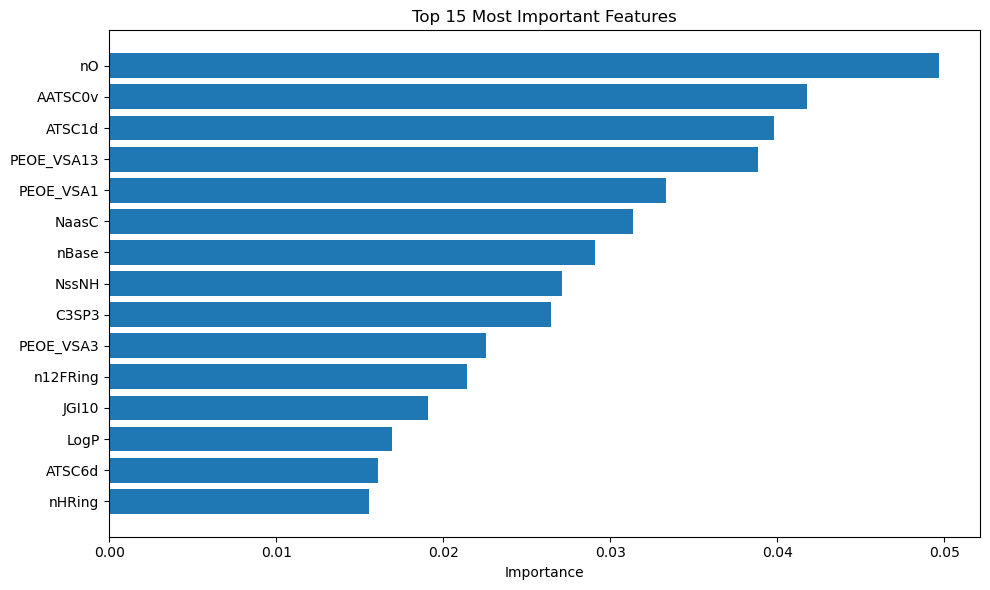

In [15]:
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': retained_features,
    'importance': importances
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

## Shap

In [16]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_scaled)

shap_values.feature_names = retained_features

In [ ]:
importance_df = pd.DataFrame({
    "feature": retained_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

top15_xgb = importance_df.head(15)["feature"].tolist()

shap_mean_abs = np.abs(shap_values.values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": retained_features,
    "mean_abs_shap": shap_mean_abs
}).sort_values("mean_abs_shap", ascending=False)

top15_shap = shap_df.head(15)["feature"].tolist()

common_features = sorted(set(top15_xgb).intersection(top15_shap))

print("Top 15 XGBoost importance features:")
print(top15_xgb)

print("\nTop 15 SHAP features:")
print(top15_shap)

print(f"\nCommon features ({len(common_features)}):")
print(common_features)

overlap_df = pd.DataFrame({
    "feature": common_features
}).merge(importance_df, on="feature", how="left").merge(shap_df, on="feature", how="left")

overlap_df

Top 15 XGBoost importance features:
['nO', 'AATSC0v', 'ATSC1d', 'PEOE_VSA13', 'PEOE_VSA1', 'NaasC', 'nBase', 'NssNH', 'C3SP3', 'PEOE_VSA3', 'n12FRing', 'JGI10', 'LogP', 'ATSC6d', 'nHRing']

Top 15 SHAP features:
['LogP', 'PEOE_VSA1', 'AATS6i', 'AATSC0v', 'SlogP_VSA3', 'PEOE_VSA8', 'JGI5', 'nBase', 'C1SP3', 'GATS5c', 'EState_VSA3', 'JGI10', 'C1SP2', 'ATSC8dv', 'ATSC1d']

Common features (6):
['AATSC0v', 'ATSC1d', 'JGI10', 'LogP', 'PEOE_VSA1', 'nBase']


,feature,importance,mean_abs_shap
0,AATSC0v,0.041796,0.330570
1,ATSC1d,0.039796,0.196384
2,JGI10,0.019092,0.210069
3,LogP,0.016935,0.647349
4,PEOE_VSA1,0.033327,0.399431
5,nBase,0.029104,0.246268


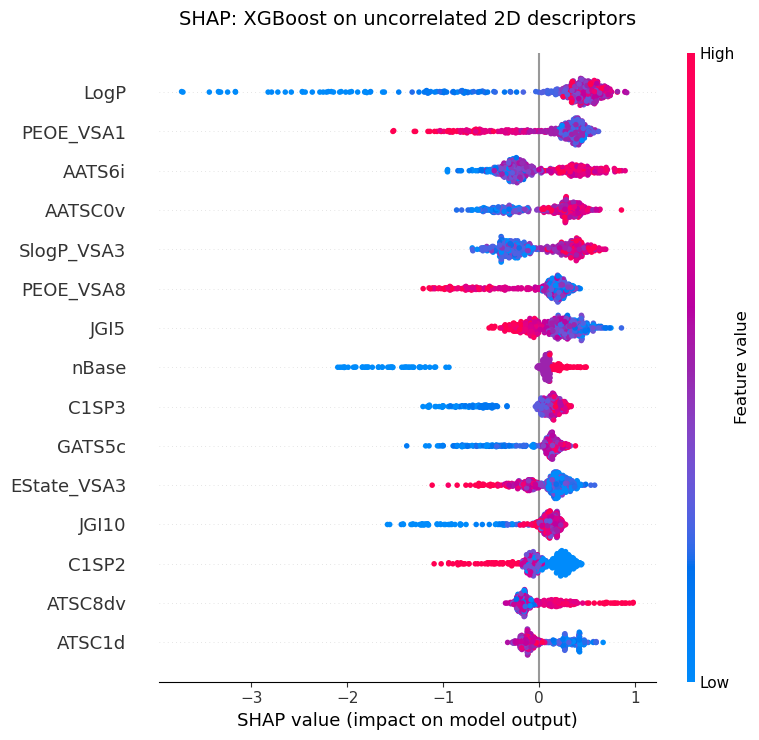

In [17]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    feature_names=retained_features, 
    max_display=15,
    show=False
)
plt.title("SHAP: XGBoost on uncorrelated 2D descriptors", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [120]:
predictions = xgb_model.predict(X_test_scaled)
active_idx = np.where(predictions == 1)[0][4]
inactive_idx = np.where(predictions == 0)[0][0]

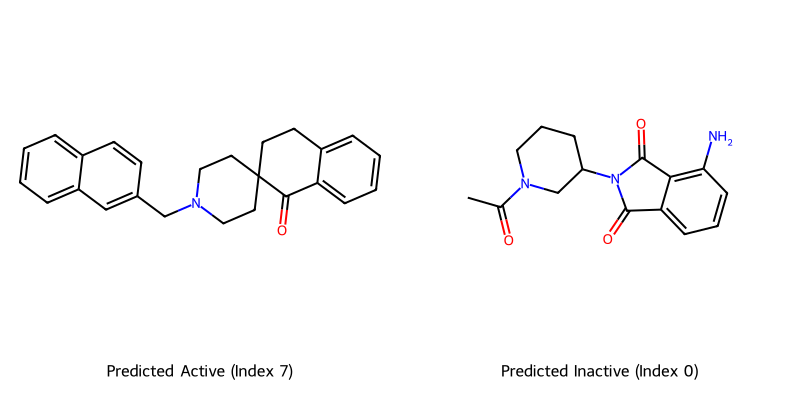

In [124]:
id_active = df_test.iloc[active_idx]['molecule_chembl_id']
id_inactive = df_test.iloc[inactive_idx]['molecule_chembl_id']

smi_active_std = df_std.loc[df_std['molecule_chembl_id'] == id_active, 'std_smiles'].values[0]
smi_inactive_std = df_std.loc[df_std['molecule_chembl_id'] == id_inactive, 'std_smiles'].values[0]

mol_active = Chem.MolFromSmiles(smi_active_std)
mol_inactive = Chem.MolFromSmiles(smi_inactive_std)

img = Draw.MolsToGridImage(
    [mol_active, mol_inactive],
    legends=[f"Predicted Active (Index {active_idx})", f"Predicted Inactive (Index {inactive_idx})"],
    molsPerRow=2,
    subImgSize=(400, 400)
)

img

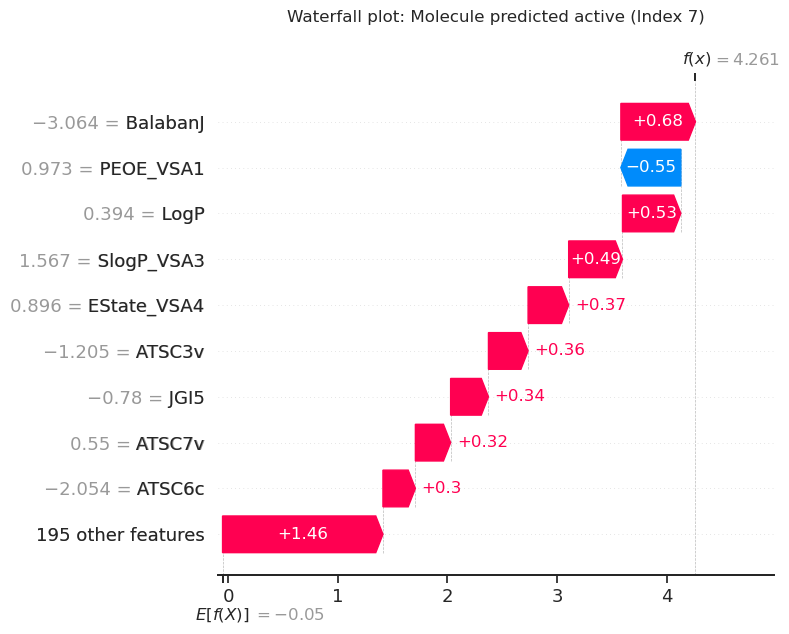

In [122]:
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[active_idx], max_display=10, show=False)
plt.title(f"Waterfall plot: Molecule predicted active (Index {active_idx})", pad=20)
plt.tight_layout()
plt.show()

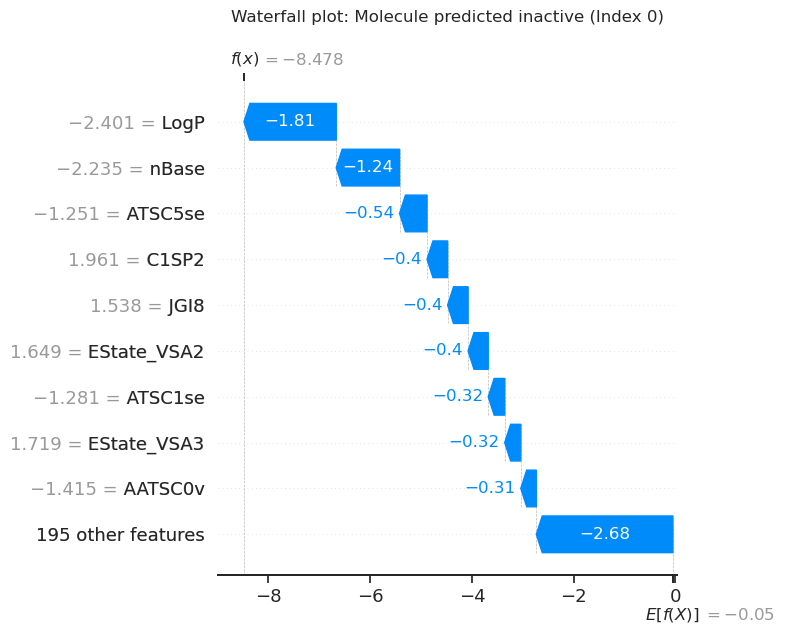

In [70]:
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[inactive_idx], max_display=10, show=False)
plt.title(f"Waterfall plot: Molecule predicted inactive (Index {inactive_idx})", pad=20)
plt.tight_layout()
plt.show()